## Titanic Dataset

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("train.csv", na_values=["?", "missing"])

Saving train.csv to train.csv


In [2]:
import matplotlib.pyplot as plt
import numpy as np

Inspecting Shape and Types

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Inspecting Missing Values

In [19]:
display(df.isnull())

print(df.isnull().sum())

print("\nTotal missing values: ", df.isnull().sum().sum())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total missing values:  866


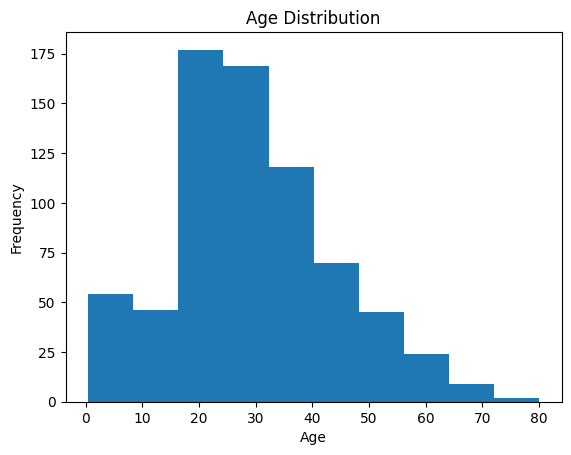

In [49]:
plt.hist(df['Age'].dropna(), bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

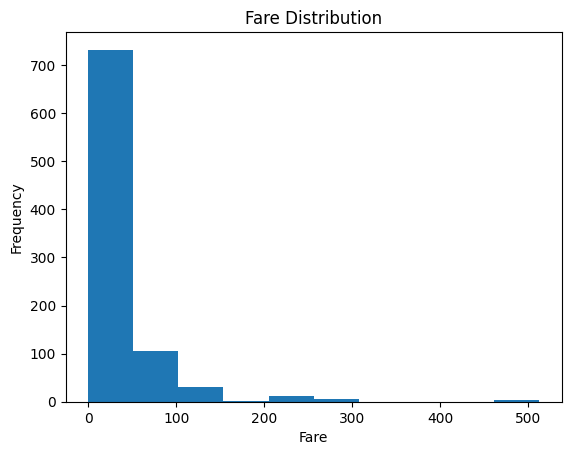

In [5]:
plt.hist(df['Fare'].dropna(), bins=10)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Fare Distribution')
plt.show()

In [6]:
print(df.select_dtypes(include='number').columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


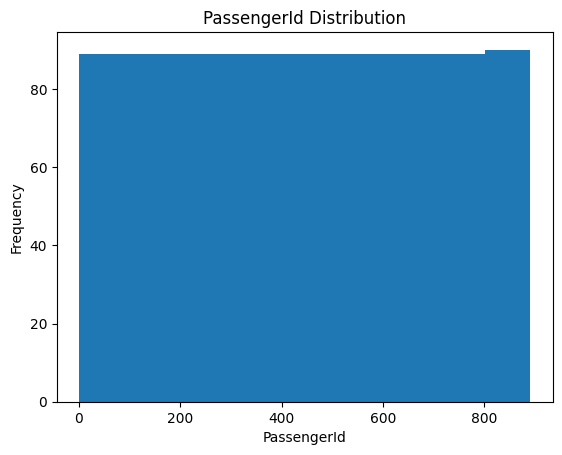

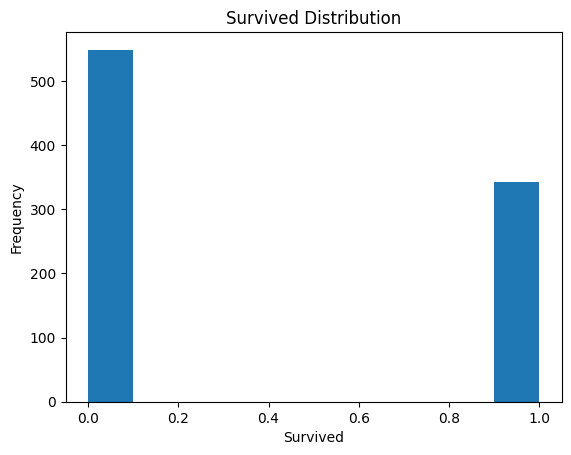

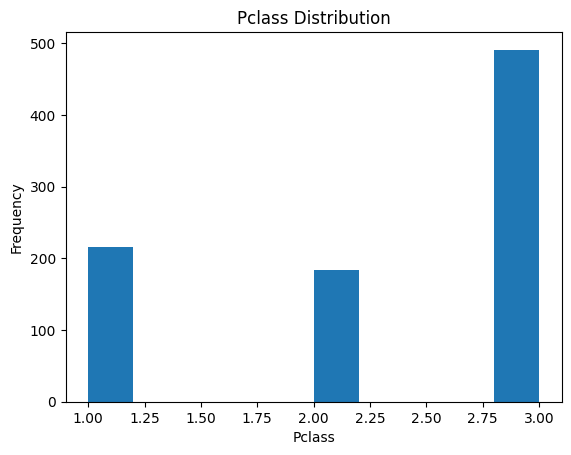

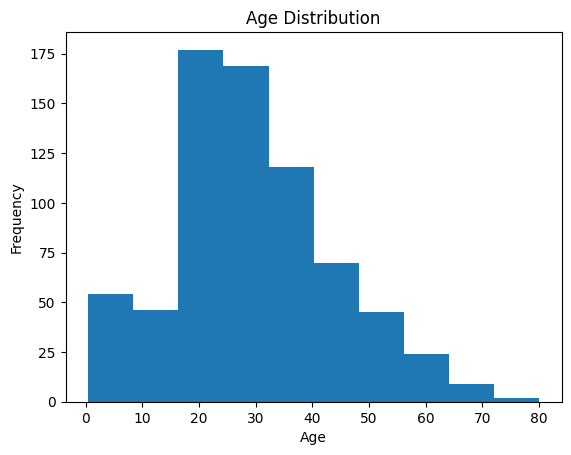

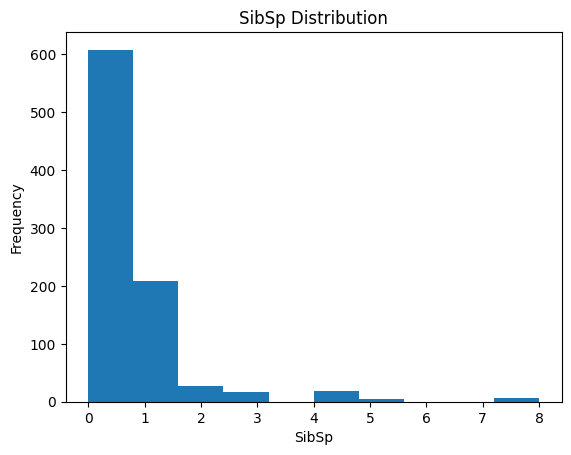

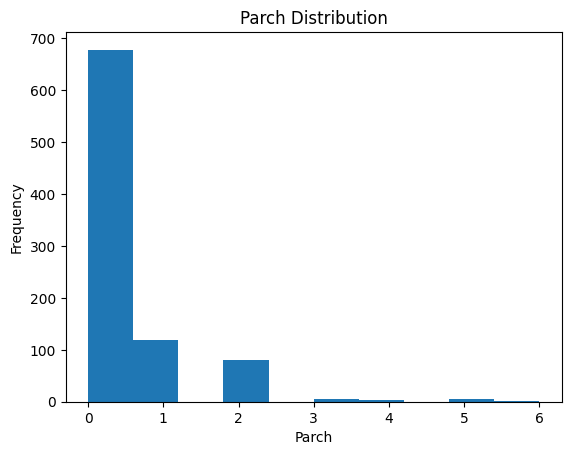

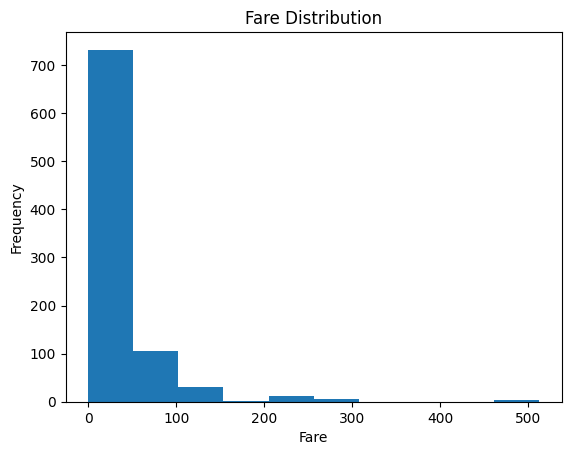

In [7]:
num_data = df.select_dtypes(include='number').columns
for col in num_data:
    plt.hist(df[col].dropna(), bins=10)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'{col} Distribution')
    plt.show()

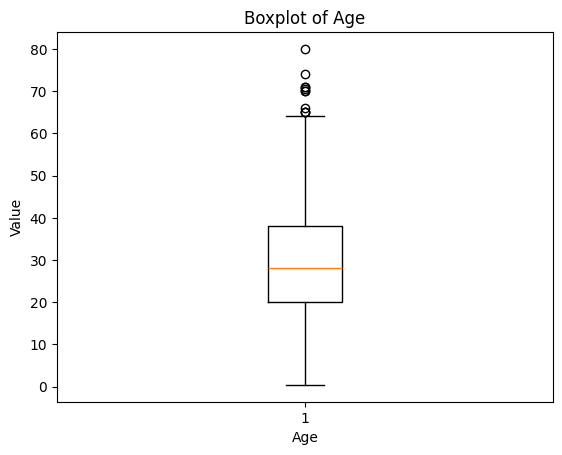

In [8]:
plt.boxplot(df["Age"].dropna())
plt.xlabel("Age")
plt.ylabel("Value")
plt.title("Boxplot of Age")
plt.show()

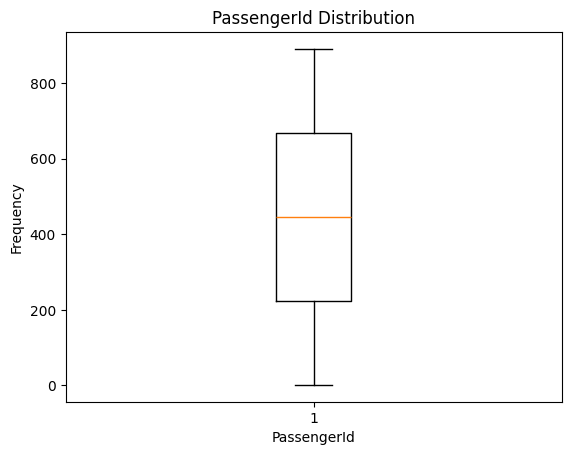

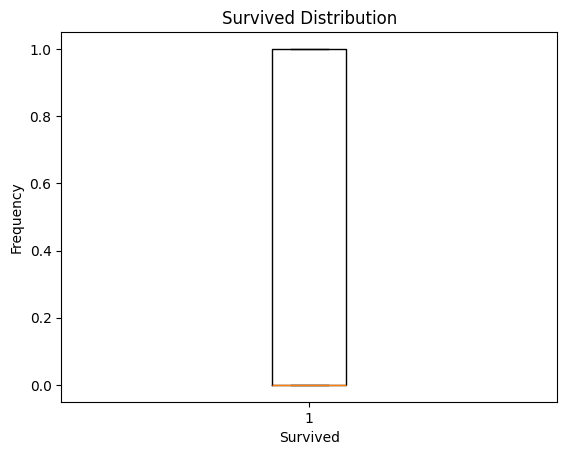

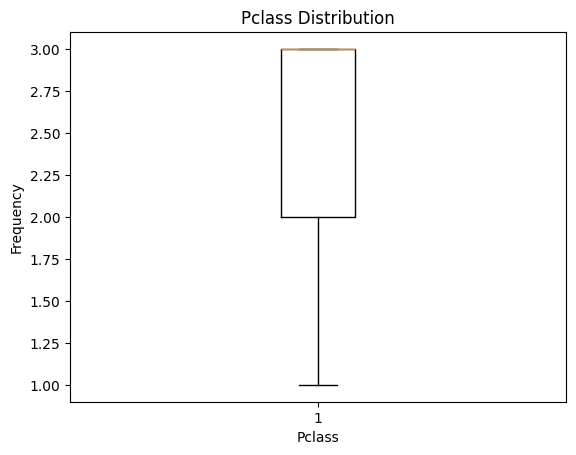

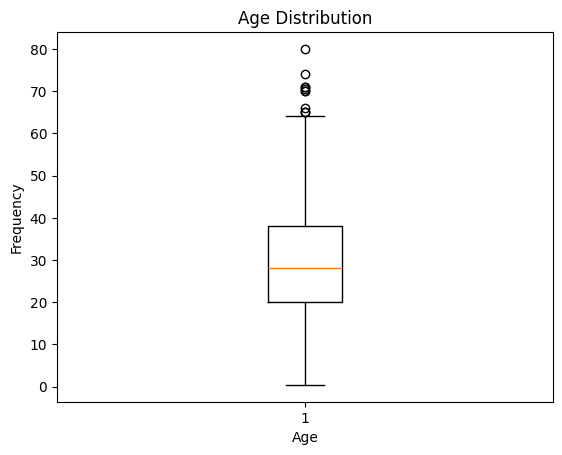

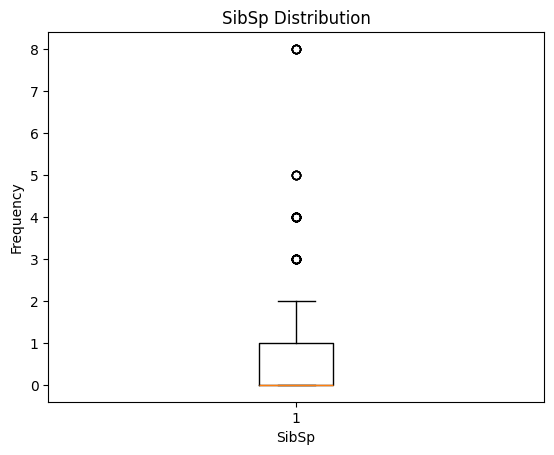

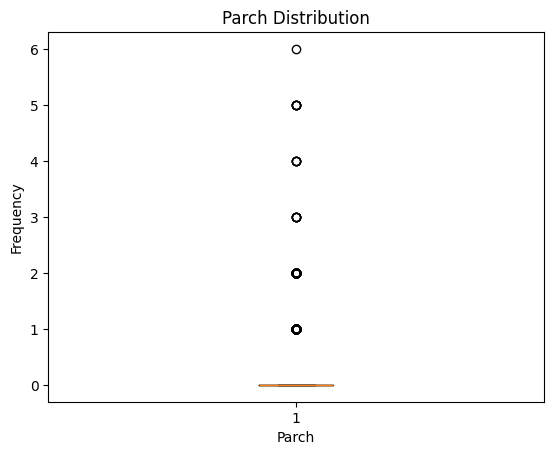

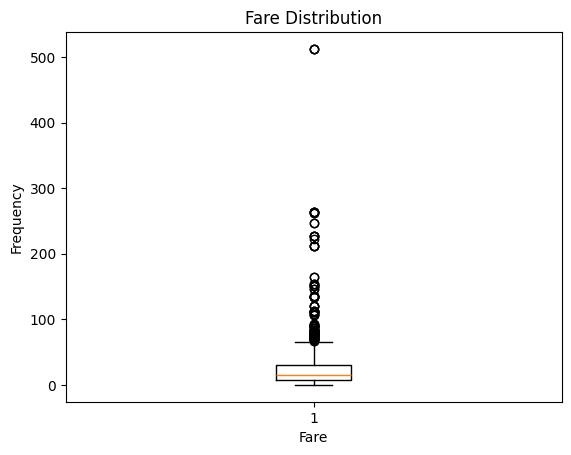

In [ ]:
num_data = df.select_dtypes(include='number').columns
for col in num_data:
    plt.boxplot(df[col].dropna())
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'{col} Distribution')
    plt.show()

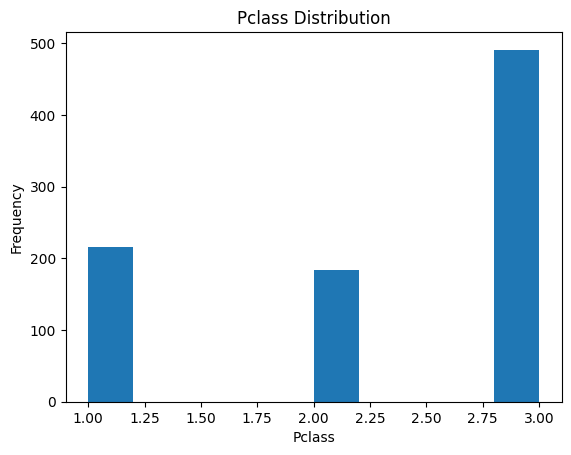

In [11]:
plt.hist(df['Pclass'].dropna(), bins=10)
plt.xlabel('Pclass')
plt.ylabel('Frequency')
plt.title('Pclass Distribution')
plt.show()

Survival Rates by Gender

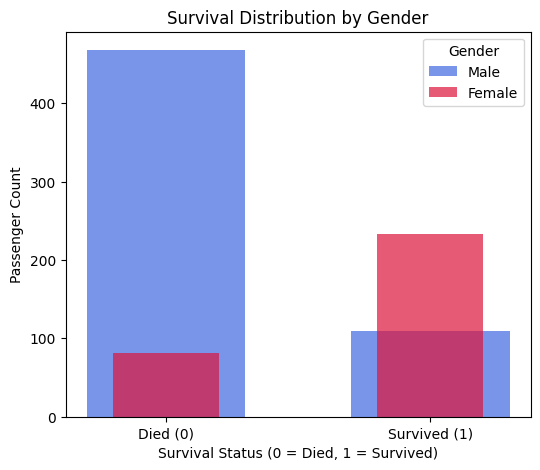

Observation: Most Survivors were females


In [56]:
male_survived = df[df['Sex'] == 'male']['Survived']
female_survived = df[df['Sex'] == 'female']['Survived']

plt.figure(figsize=(6, 5))
plt.hist(male_survived, bins=[-0.5, 0.5, 1.5], rwidth=0.6, alpha=0.7, label='Male', color='royalblue')
plt.hist(female_survived, bins=[-0.5, 0.5, 1.5], rwidth=0.4, alpha=0.7, label='Female', color='crimson')

plt.title('Survival Distribution by Gender')
plt.xlabel('Survival Status (0 = Died, 1 = Survived)')
plt.ylabel('Passenger Count')
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'])
plt.legend(title='Gender')

plt.show()
print('Observation: Most Survivors were females')

Survival Rates by Passenger Class

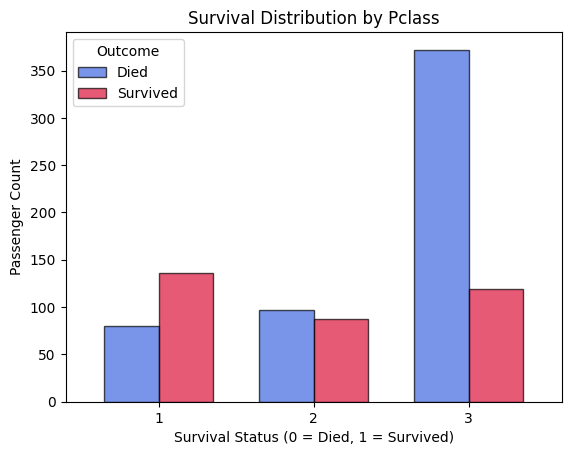

In [36]:
class_survival = df.groupby(['Pclass', 'Survived']).size().unstack()

class_survival.plot(kind='bar', color=['royalblue', 'crimson'], width=0.7, alpha = 0.7, edgecolor='black')

plt.title('Survival Distribution by Pclass')
plt.xlabel('Survival Status (0 = Died, 1 = Survived)')
plt.ylabel('Passenger Count')
plt.xticks(rotation=0)
plt.legend(title='Outcome', labels=['Died', 'Survived'])
plt.show()

print('Observation: Most survivors belonged to Passenger Class 1')

Survival Rates by Age Group

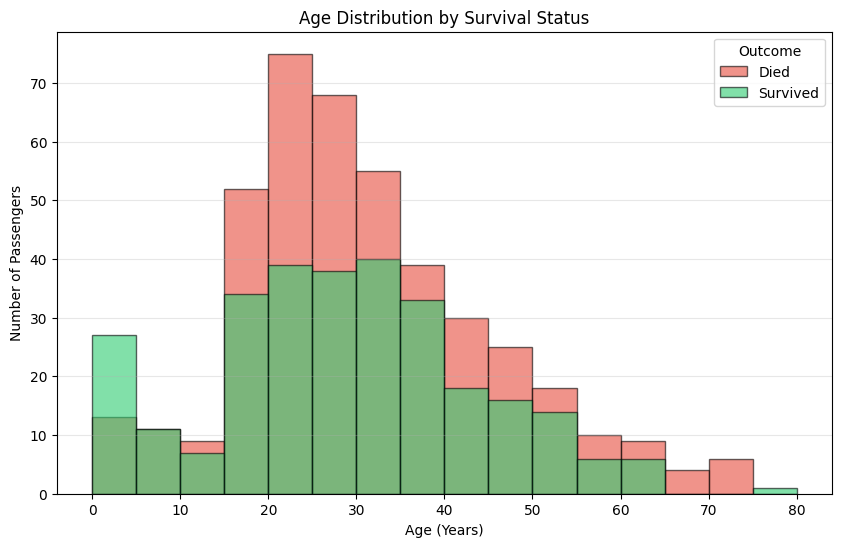

Observation: Most survivors belonged to the age group 15-40 years


In [55]:
df_clean = df.dropna(subset=['Age'])
age_died = df_clean[df_clean['Survived'] == 0]['Age']
age_survived = df_clean[df_clean['Survived'] == 1]['Age']

# 4. Plot overlapping histograms
plt.figure(figsize=(10, 6))

# Define bins to group ages by 5-year increments from 0 to 80
bins = range(0, 85, 5)

plt.hist(age_died, bins=bins, alpha=0.6, label='Died', color='#e74c3c', edgecolor='black')
plt.hist(age_survived, bins=bins, alpha=0.6, label='Survived', color='#2ecc71', edgecolor='black')

# 5. Customize the chart
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Passengers')
plt.legend(title='Outcome')
plt.grid(axis='y', alpha=0.3)  # Add faint gridlines for easier scanning

plt.show()
print('Observation: Most survivors belonged to the age group 15-40 years')